# Tesla Deliveries Forecasting

This project analyzes Tesla vehicle production and delivery data from 2015–2025. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, regression modeling, model evaluation, and delivery forecasting.


## Project Overview

This project analyzes Tesla production and delivery data from 2015–2025 and develops an end-to-end machine learning pipeline for delivery forecasting.

Key Tasks:
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression Modeling
- Model Evaluation
- Forecasting

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import joblib
print('All libraries loaded successfully')

All libraries loaded successfully


In [2]:
df=pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


In [3]:
df.head(10)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


## Data Inspection

The dataset was explored to understand its structure, feature types, and statistical properties before analysis and modeling.

Checks Performed:
- Dataset Shape
- Data Types
- Summary Statistics
- Feature Overview

In [4]:
df.sample(5)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
1722,2017,11,Europe,Cybertruck,5328,5502,62798.64,60,354,282.92,Estimated (Region),6428
1678,2024,1,Asia,Cybertruck,8253,8377,97159.82,100,550,680.87,Interpolated (Month),8703
1541,2025,9,Middle East,Model 3,10184,11005,104650.26,75,424,647.70,Interpolated (Month),8782
358,2017,4,North America,Cybertruck,10057,10390,52725.10,120,662,998.66,Estimated (Region),5102
409,2018,4,Europe,Model 3,10049,10153,56291.38,100,580,874.26,Estimated (Region),7091


In [5]:
df.shape

(2640, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [7]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Data Quality Check

Data quality checks were performed before model development.

Results:
- No Missing Values Found
- No Duplicate Records Found
- Dataset Ready for Analysis

In [8]:
print('Missing Values')
df.isnull().sum()

Missing Values


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [9]:
print('Duplicated Values')
df.duplicated().sum()

Duplicated Values


0

## Exploratory Data Analysis (EDA)

EDA was conducted to identify trends, distributions, and relationships among variables.

Analysis Included:
- Delivery Trends
- Production Patterns
- Feature Distributions
- Variable Relationships

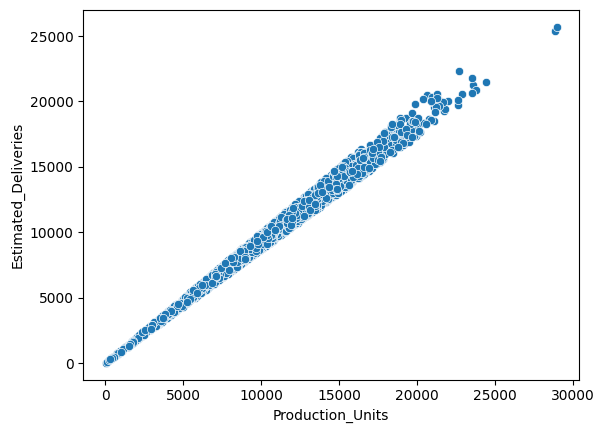

In [10]:
sns.scatterplot(data=df,x='Production_Units',y='Estimated_Deliveries')
plt.show()

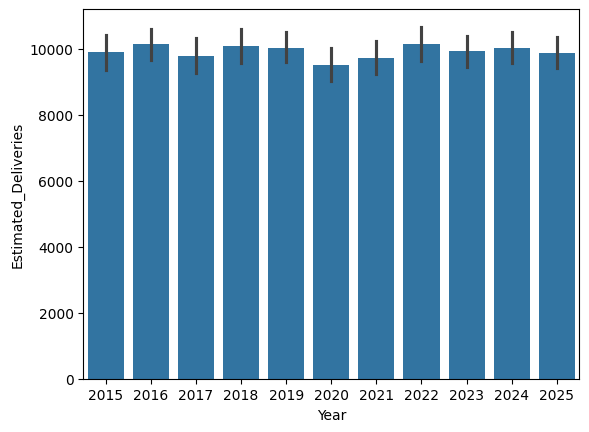

In [11]:
sns.barplot(data=df,x='Year',y='Estimated_Deliveries')
plt.show()

## Vehicle Model and Region Distribution

Pie charts are generated to visualize the distribution of vehicle models and regions within the dataset.

Result:
- Shows the proportion of each vehicle model.
- Shows the contribution of each region.

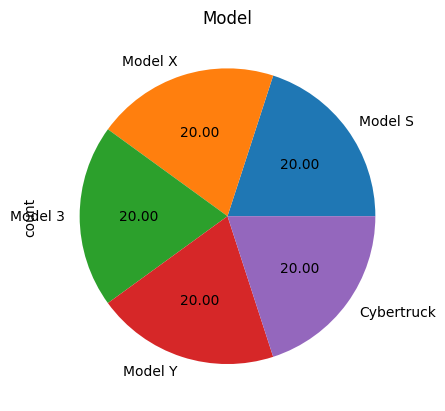

<Figure size 300x400 with 0 Axes>

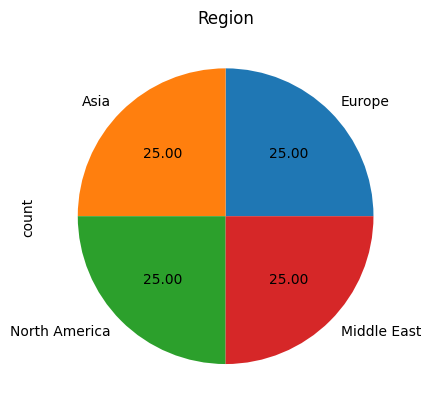

<Figure size 300x400 with 0 Axes>

In [12]:
label=['Model','Region']
for i in label:
    df[i].value_counts().plot(kind='pie',autopct='%.2f')
    plt.title(i)
    plt.subplot(111)
    plt.figure(figsize=(3,4))
    plt.show()

## Numerical Feature Distribution

Distribution plots are generated for important numerical features to understand their spread and density.

Result:
- Reveals data concentration and spread.
- Helps identify skewed distributions.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4168\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


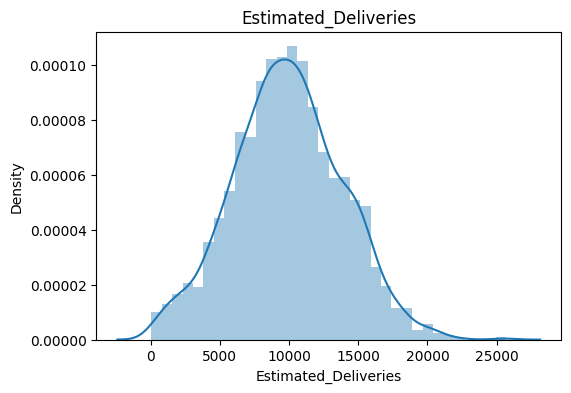

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4168\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


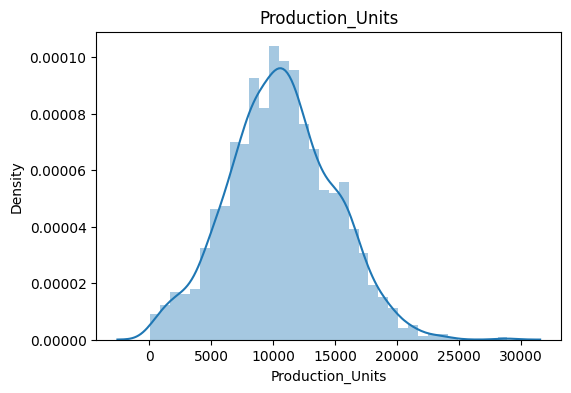

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4168\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


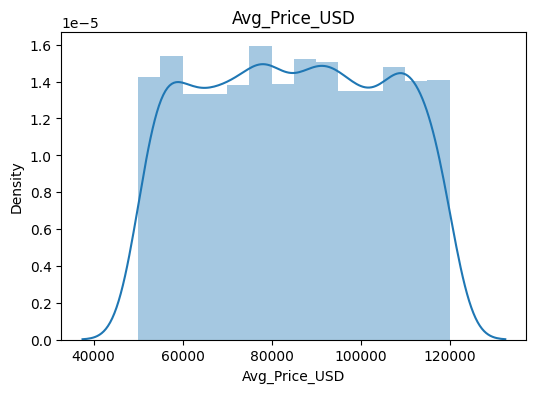

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4168\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


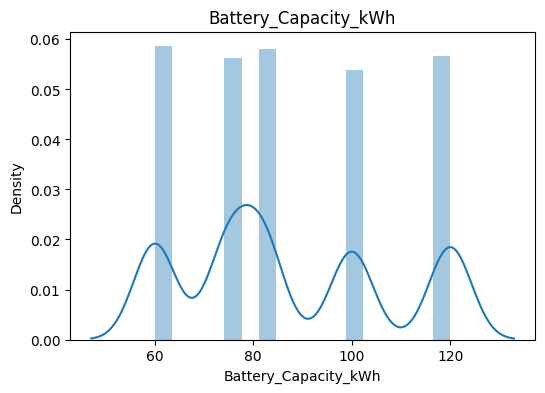

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4168\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


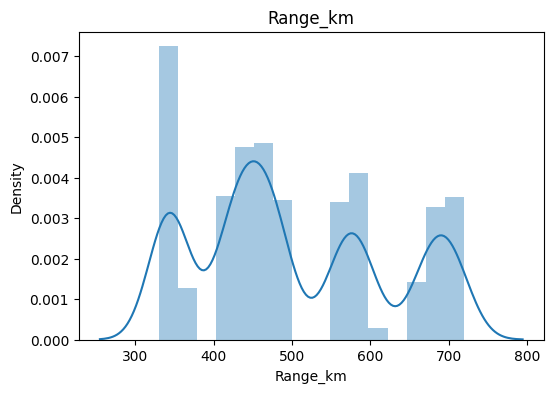

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4168\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


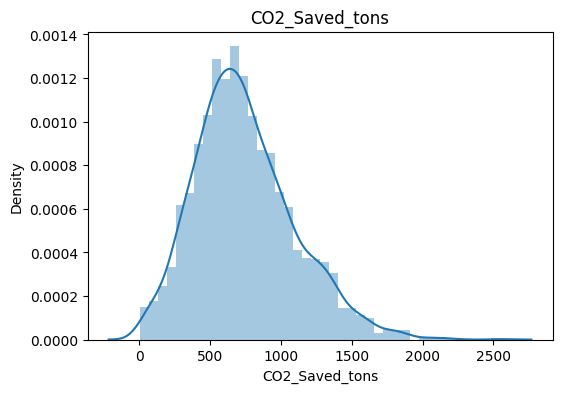

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4168\3147243417.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i],kde=True)


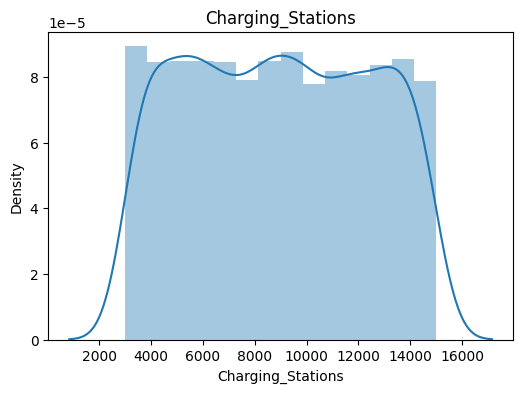

In [13]:
plot=['Estimated_Deliveries',	'Production_Units',	'Avg_Price_USD',	'Battery_Capacity_kWh',	'Range_km',	'CO2_Saved_tons','Charging_Stations']
for i in plot:
    plt.figure(figsize=(6,4))
    sns.distplot(df[i],kde=True)
    plt.title(i)
    plt.show()

## Histogram Analysis

Histograms are created to visualize the frequency distribution of numerical variables.

Result:
- Shows common value ranges.
- Provides a better understanding of feature behavior.

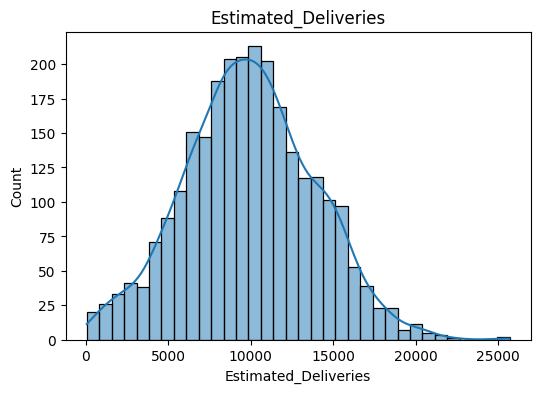

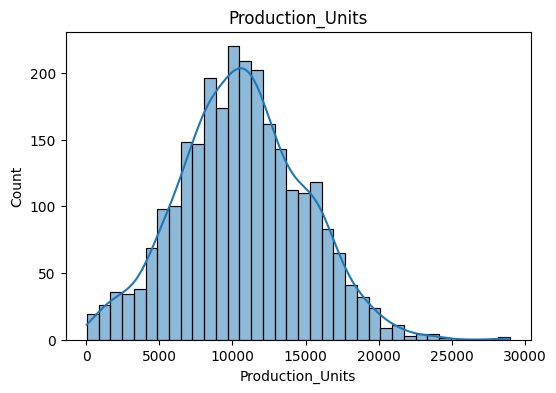

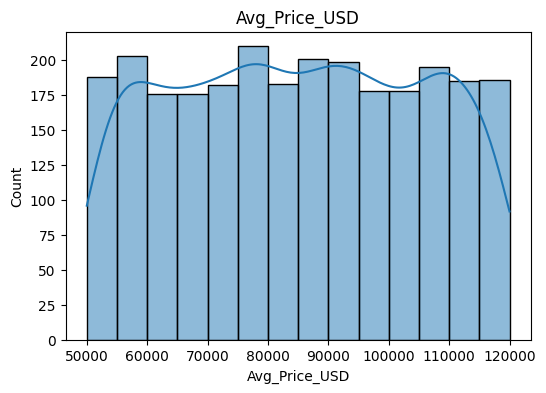

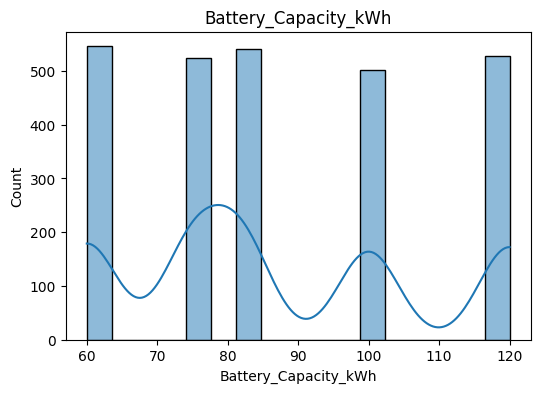

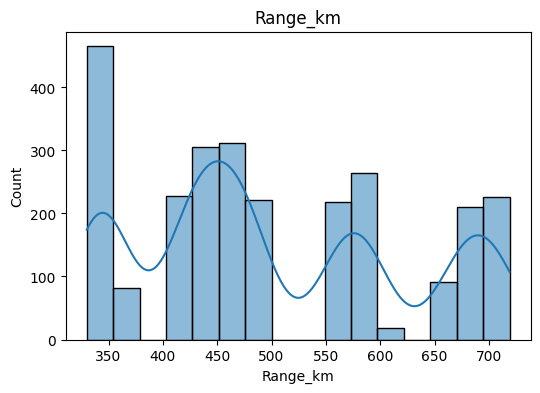

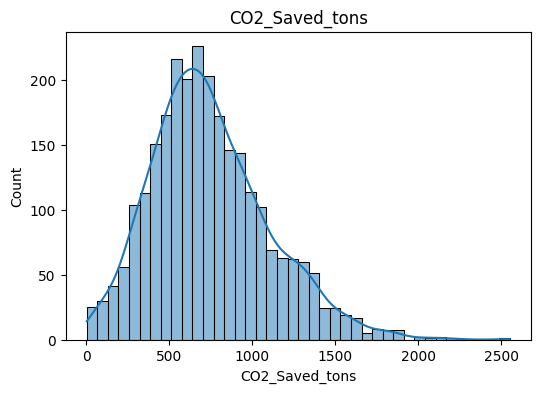

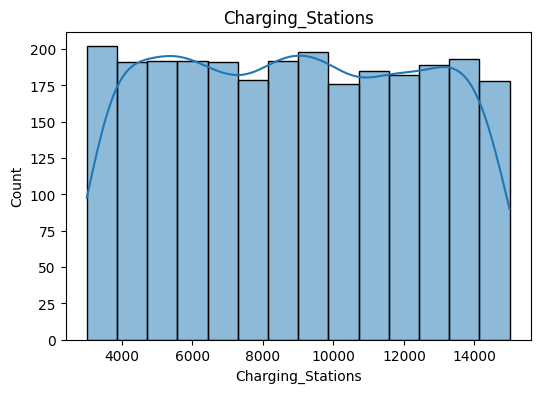

In [14]:
plots=['Estimated_Deliveries',	'Production_Units',	'Avg_Price_USD',	'Battery_Capacity_kWh',	'Range_km',	'CO2_Saved_tons','Charging_Stations']
for i in plots:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],kde=True)
    plt.title(i)
    plt.show()
    

## Time Series Trend Analysis

A date column is created using Year and Month values, and delivery trends are visualized over time.

Result:
- Displays delivery patterns across multiple years.
- Helps identify growth and seasonal trends.

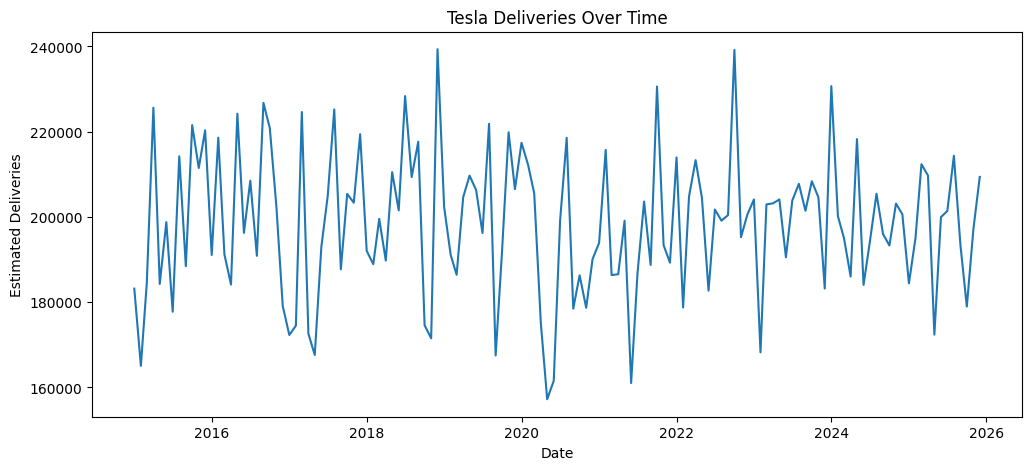

In [15]:
df["Date"] =pd.to_datetime(df["Year"].astype(str)+ "-"+ df["Month"].astype(str))
monthly_sales = (df.groupby("Date")["Estimated_Deliveries"].sum())
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index,monthly_sales.values)
plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

In [16]:
df = df.drop(columns=['Date'])

## Correlation Analysis

A correlation heatmap was generated to examine relationships between numerical features.

Objectives:
- Identify Important Features
- Detect Strong Correlations
- Support Feature Selection

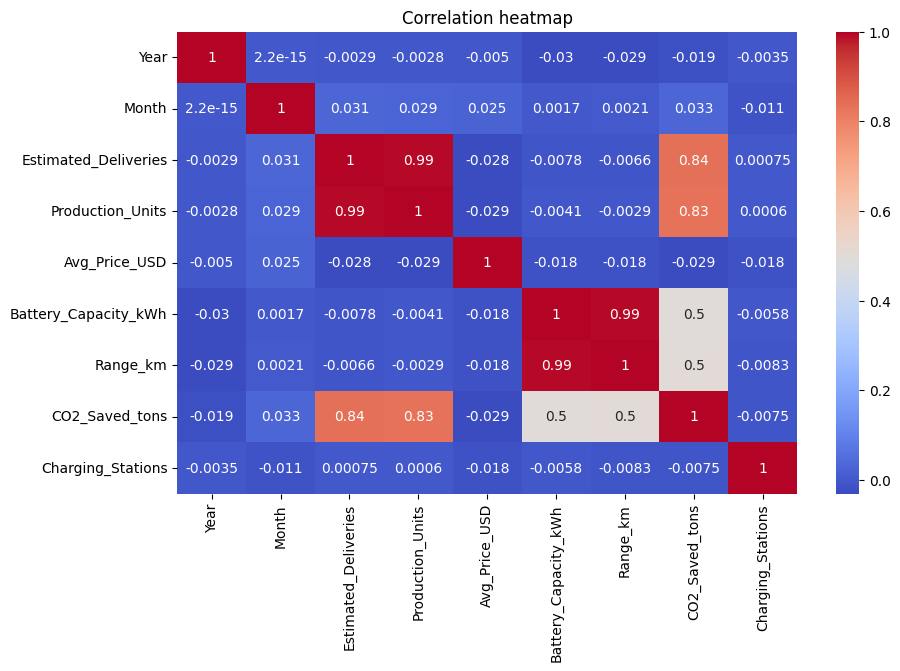

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()


## Feature and Target Definition

The target variable is separated from the input features to prepare the dataset for machine learning.

Result:
- `X` contains independent variables.
- `y` contains the delivery values to be predicted.

In [18]:
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

## Feature Engineering

Additional time-based features were created to improve model performance.

Features Created:
- Month Sine Encoding
- Month Cosine Encoding
- Year Transformation

In [19]:
df['month_sin'] = np.sin(2*np.pi*df['Month']/12)
df['month_cos'] = np.cos(2*np.pi*df['Month']/12)

In [20]:
df['Year'] = df['Year'] - df['Year'].min()

## Feature Categorization

Numerical and categorical features are identified separately for preprocessing.

Result:
- Numerical columns are stored in `nume_col`.
- Categorical columns are stored in `cate_col`.

In [21]:
print('Identifying the numerical and categorical Feature')
nume_col=X.select_dtypes(include=['int64','float64']).columns.tolist()
cate_col=X.select_dtypes(include='object').columns.tolist()
print(f"Numerical Features: {nume_col}\n")
print(f"Categorical Features: {cate_col}")

Identifying the numerical and categorical Feature
Numerical Features: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

Categorical Features: ['Region', 'Model', 'Source_Type']


## Categorical Feature Exploration

The frequency of each category is examined for categorical variables.

Result:
- Displays category counts.
- Helps understand category distributions.

In [22]:
print('Identifying the sub categories in the categorical features\n')
for i in cate_col:
    print(f'{df[i].value_counts()}\n')

Identifying the sub categories in the categorical features

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64



## Data Preprocessing Pipeline

A preprocessing pipeline is created using scaling for numerical features and encoding for categorical features.

Pipeline Components:
1. StandardScaler
2. OneHotEncoder

Result:
- Data is prepared for machine learning algorithms.

In [23]:
processor=ColumnTransformer(transformers=[
    ('num',StandardScaler(),nume_col),
    ('cat',OneHotEncoder(handle_unknown='ignore'),cate_col)
],remainder='passthrough')

## Train-Test Split

The dataset is divided into training and testing sets.

Configuration:
- 80% Training Data
- 20% Testing Data

Result:
- Training data is used for learning.
- Testing data is used for evaluation.

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
print(X_train.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type',
       'Charging_Stations'],
      dtype='object')


In [26]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,month_sin,month_cos
0,8,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,5.000000e-01,-0.866025
1,0,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,8.660254e-01,0.500000
2,4,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,5.000000e-01,0.866025
3,6,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,8.660254e-01,0.500000
4,1,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,-2.449294e-16,1.000000


## Regression Model Development

A Linear Regression model is integrated with the preprocessing pipeline.

Pipeline Components:
1. Data Preprocessing
2. Feature Transformation
3. Linear Regression

Result:
- Creates a complete machine learning workflow.

In [27]:
pipe = Pipeline([
    ('processor', processor),
    ('model', LinearRegression())
])

## Model Training

The pipeline is trained using the training dataset.

Result:
- The model learns relationships between input features and estimated deliveries.

In [29]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('processor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Year', 'Month',
                                                   'Production_Units',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', LinearRegression())])

## Delivery Prediction

Predictions are generated using the trained model on unseen test data.

Result:
- Predicted delivery values are stored in `y_pred`.

In [30]:
y_pred = pipe.predict(X_test)

In [31]:
y_pred.tolist()

[7571.600001457937,
 9433.89473939124,
 8799.017878963088,
 9366.321985159828,
 8922.60215210729,
 11482.73413252483,
 14204.7088197214,
 14341.476515619026,
 10003.073095866,
 7858.434134677137,
 8552.280913933504,
 9910.327333366024,
 9660.867723784,
 3130.755044006888,
 10373.78141372012,
 5960.770420305724,
 11566.507853034365,
 11772.4341761896,
 17073.869378080257,
 10900.994972445225,
 10596.527166768237,
 7750.474563137417,
 9682.845719884259,
 10561.465041001165,
 8194.550641488548,
 6187.790514325889,
 13352.182654790562,
 4502.077299359916,
 10689.216433507558,
 3427.1774033803204,
 8551.628257531404,
 13887.97460400223,
 14723.518366118737,
 15746.02231218163,
 13937.367493015969,
 12722.969009652927,
 4379.0401576172835,
 9412.100192013899,
 4827.982522714792,
 14630.11433753607,
 9333.707650334658,
 9079.813495924796,
 5998.218387143988,
 16033.062133368778,
 7630.124855035701,
 4929.686166738949,
 10433.212988260642,
 4461.694992594435,
 2073.315618946858,
 15453.5008590

## Actual vs Predicted Comparison

Actual delivery values are compared with model predictions.

Result:
- A comparison table is generated.
- Helps visually assess prediction accuracy.

In [32]:
forecast=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
forecast

,Actual,Predicted
2005,6991,7571.600001
32,9326,9433.894739
962,9061,8799.017879
1461,8951,9366.321985
478,8707,8922.602152
...,...,...
2033,18572,19123.109199
279,1761,1965.343810
2443,10136,10707.193283
2356,17905,18265.209067


## Model Evaluation

Model performance was evaluated using multiple regression metrics.

Metrics Used:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

In [33]:
lr_mae = mean_absolute_error(y_test, y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_r2 = r2_score(y_test,y_pred)
print("---------------------")
print("MAE :", round(lr_mae,2))
print("RMSE:", round(lr_rmse,2))
print("R²  :", round(lr_r2,4))

---------------------
MAE : 309.7
RMSE: 384.03
R²  : 0.9901


## Cross Validation

K-Fold Cross Validation was performed to assess model reliability.

Benefits:
- Reduced Overfitting Risk
- Better Generalization Assessment
- Stable Performance Measurement

In [34]:
scores = cross_val_score(pipe,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)
print("Cross Validation Scores:", scores)
print("Mean CV Score:", scores.mean())
print("Std CV Score:", scores.std())

Cross Validation Scores: [0.99055199 0.99044416 0.99005516 0.98946291 0.99048545]
Mean CV Score: 0.9901999337873952
Std CV Score: 0.0004072532581680656


## Model Persistence

The trained model is saved using Joblib for future use.

Result:
- A reusable file named `tesla_delivery_model.pkl` is created.
- The model can be loaded later without retraining.

In [36]:
joblib.dump(pipe, "tesla_delivery_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


## Conclusion

A complete machine learning pipeline was successfully developed for Tesla delivery forecasting.

Achievements:
- Clean Data Analysis
- Feature Engineering
- Regression Modeling
- Model Evaluation
- Delivery Forecasting